# Source: https://scikit-learn.org/stable/auto_examples/decomposition/plot_image_denoising.html

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import sklearn
import scipy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.decomposition import SparseCoder, sparse_encode
from sklearn.linear_model import orthogonal_mp_gram
from scipy.sparse.linalg import svds

import numba
from numba import njit, prange


seed = 42
rng = np.random.default_rng(seed)

## Import test image from scipy

In [2]:
from scipy.datasets import face

raccoon_face = face(gray=True).astype(np.float64)

# normalize
raccoon_face /= 255.0

# downsample for speed
raccoon_face = raccoon_face[::4, ::4] + raccoon_face[2::4, ::4] + raccoon_face[::4, 2::4] + raccoon_face[2::4, 2::4]
raccoon_face /= 4
height, width = raccoon_face.shape

# Distort the right half of the image
print('Distorting image')
distorted = raccoon_face.copy()
distorted[:, width // 2:] += .075 * rng.standard_normal(size=(height, width // 2))

Distorting image


## Display distorted image

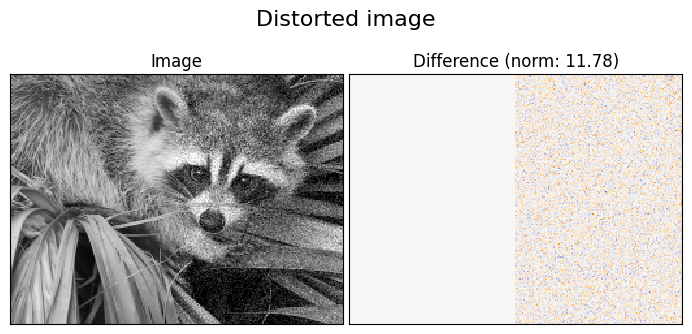

In [3]:
def show_with_diff(image, reference, title):
    plt.figure(figsize=(7, 3.3))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
    
    plt.subplot(1, 2, 2)
    difference = image - reference

    plt.title('Difference (norm: %.2f)' % np.sqrt(np.sum(difference**2)))
    plt.imshow(
        difference, vmin=-0.5, vmax=0.5, cmap=plt.cm.PuOr, interpolation='nearest'
    )
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(title, size=16)
    plt.subplots_adjust(.02, .02, .98, .79, .02, .2)

show_with_diff(distorted, raccoon_face, 'Distorted image')

## Extract reference patches

In [4]:
from time import time
from sklearn.feature_extraction.image import extract_patches_2d

# Extract patches from left half of the image
print('Extracting reference patches')
t0 = time()
patch_size = (7, 7)
data = extract_patches_2d(distorted[:, :width // 2], patch_size)
data = data.reshape(data.shape[0], -1)
data -= np.mean(data, axis=0)
data /= np.std(data, axis=0)
print(f'{data.shape[0]} patches extracted in %.2fs.' % (time() - t0))

Extracting reference patches
22692 patches extracted in 0.02s.


# Baseline (Serial_V3_1.py)

In [5]:
def OMP_baseline(Y, T_0, D, batch_size = 1, rng=42, debug=False):
    # loss = np.empty(num_iter)
    # rng = np.random.default_rng(rng)

    X = np.zeros((Y.shape[0], D.shape[0]))
    D_norm = np.linalg.norm(D, axis=1, keepdims=True)

    splits = np.arange(0, Y.shape[0], step=batch_size)
    Y_batches = np.split(Y, splits)[1:]
    
    for i, y in enumerate(Y_batches):
        if i == (len(Y_batches) - 1):
            batch_size = np.arange(splits[i], len(Y)).shape[0]
            if debug:
                print(f'batch_size = {batch_size}')
        I = np.empty((batch_size, T_0), dtype=np.int32)
        D_I = np.zeros((batch_size, T_0, D.shape[1]))
        r = y   # (batch_size, D.shape[1])
        gamma = 0
        Q = np.empty((batch_size, D.shape[1], T_0))
        R = np.empty((batch_size, T_0, T_0))
        
        for j in range(T_0):
            if debug:
                print(f'Batch {i}, Iteration {j}')
                print(f'r shape: {r.shape}')
            D_r = np.abs(r @ D.T)
            k = np.argmax(D_r, axis = 1)
            
            I[:, j] = k
            D_I[:, j] = D[k]

            if j == 0:
                D_k_norm = D_norm[k]
                R[:, 0, 0] = D_k_norm[:, 0]
                Q[:, :, 0] = D[k] / D_k_norm
                
                if debug:
                    print(D_k_norm)
                    print(np.sum(Q[:, :, 0] ** 2, axis = 1))
                    print(R[:, 0, 0])

                gamma = np.squeeze(y[:, np.newaxis] @ Q[:, :, :1], axis=1) 
                gamma /= D_k_norm
                
            else:
                if debug:
                    print(np.transpose(Q[:, :, :j], (0, 2, 1)).shape)
                    print(D[k][..., np.newaxis].shape)
                # dot = np.transpose(Q[:, :, :j], (0, 2, 1)) @ D[k][..., np.newaxis]
                dot = np.squeeze(D[k][:, np.newaxis] @ Q[:, :, :j], axis=1)
                
                # R[:, 0:j, j] = dot[0]
                R[:, 0:j, j] = dot
                
                # q_j = D[k] - (Q[:, :, :j] @ dot)[..., 0]
                q_j = D[k] - np.squeeze(Q[:, :, :j] @ dot[..., np.newaxis], axis = -1)
                
                # q_j_norm = np.linalg.norm(q_j)
                q_j_norm = np.linalg.norm(q_j, axis = 1)
                
                R[:, j, j] = q_j_norm
                # Q[:, :, j] = q_j / q_j_norm
                Q[:, :, j] = q_j / q_j_norm[:, np.newaxis]
                

                if debug:            
                    print(Q[:, :, :j+1].shape)
                    print(y.shape)
                Q_T_y = np.transpose(y[:, np.newaxis] @ Q[:, :, :j+1], (0, 2, 1))
                gamma = LA.solve_triangular(R[:, :j+1, :j+1], 
                                        Q_T_y, 
                                        overwrite_b = True,
                                        check_finite = False)
                if debug:
                    print(f'original gamma shape: {gamma.shape}')
                # gamma = np.transpose(gamma, (0, 2, 1))
                gamma = np.squeeze(gamma, axis=-1)
                

            if debug:
                print(gamma.shape)
                print(f'D_I shape: {D_I[:, :j+1].shape}')
                print(f'y shape: {y.shape}')
            # est = (np.transpose(D_I[:, :j+1], (0, 2, 1)) @ gamma[..., np.newaxis])[..., 0] 
            est = np.squeeze(gamma[:, np.newaxis] @ D_I[:, :j+1], axis=1)
            if debug:
                print(f'est shape: {est.shape}')
            r = y - est
            # if r.ndim > 2:
                # r = np.transpose(r, (0, 2, 1))
            if debug:
                print(r.shape)
            if debug:
                print(np.sum(r * r, axis = -1))
                # print(res)

        # X[i, I] = gamma
        if i == (len(Y_batches) - 1):
            if debug:
                # print(splits[i].dtype)
                # print(I.dtype)
                print(f'gamma: {gamma}')
                print(f'gamma shape: {gamma.shape}')
                print(f'k shape: {k.shape}')
                print(f'I shape: {I.shape}')
            # if T_0 == 1:
            #     X[np.arange(splits[i], len(Y)), I[:, 0]] = gamma[:, 0]
            # else:
            #     X[np.arange(splits[i], len(Y))[:, np.newaxis], I] = gamma[:, 0, :]
            X[np.arange(splits[i], len(Y))[:, np.newaxis], I] = gamma
            
        elif i == 0:
            X[np.arange(0, splits[1])[:, np.newaxis], I] = gamma
        else:
            X[np.arange(splits[i], splits[i+1])[:, np.newaxis], I] = gamma

        if debug:
            print()
    return X

In [6]:
def kSVD_baseline(Y, T_0, k, num_iter, batch_size = 1, track_loss = True, verbose:int = 0, rng=42):
    loss = np.empty(num_iter)
    rng = np.random.default_rng(rng)

    # Initialize dictionary
    t0 = time()
    D = rng.standard_normal(size=(k, Y.shape[1]))
    D /= LA.norm(D, ord=2, axis=1)[:, np.newaxis]

    if verbose > 0:
        print(f'Initialization Time: {time() - t0}')
    
    for iter in range(num_iter):
        t0 = 0
        if verbose > 0:
            print(f'Iteration {iter}:')
            t0 = time()
        
        # gram = D @ D.T
        # cov = D @ Y.T
        # X = orthogonal_mp_gram(
        #     Gram=gram, 
        #     Xy=cov, 
        #     n_nonzero_coefs=T_0, 
        #     copy_Gram=False, 
        #     copy_Xy=False
        # ).T # Transpose to match X shape
        X = OMP_baseline(Y, T_0, D, batch_size = batch_size, rng=rng, debug=False)
        # X = np.asfortranarray(X)
        if verbose > 0:
            print(f'\tCoding Time: {time() - t0}')
        
        t0 = time()
        unused_atom = False
        # XD = X @ D
        filter_bool = (X != 0)
        E_k_R = Y - X @ D
        for i in range(k):
            # x_i = X[:, i]
            filter_bool_i = filter_bool[:, i]
            
            # filter = np.flatnonzero(x_i)
            # filter = np.nonzero(x_i)[0]
            filter = np.flatnonzero(filter_bool_i)
            
            # x_i_R = x_i[filter]
            
            # if x_i_R.shape[0] == 0:
            if filter.shape[0] == 0:
                unused_atom=True
                continue
            
            # res = X[filter, i][:, np.newaxis] * D[i]
            # XD[filter] -= res
            # E_k_R = Y[filter] - XD[filter]
            E_k_R[filter] += X[filter, i][:, np.newaxis] * D[i]

            # U, S, Vh = LA.svd(E_k_R, full_matrices=False)
            # U, S, Vh = LA.svd(E_k_R[filter], full_matrices=False)
            U, S, Vh = np.linalg.svd(E_k_R[filter], full_matrices=False)

            X[filter, i] = U[:, 0] * S[0]
            D[i] = Vh[0]

            # XD[filter] += X[filter, i][:, np.newaxis] * D[i]
            E_k_R[filter] -= X[filter, i][:, np.newaxis] * D[i]

        if verbose > 0:
            print(f'\tUpdate Time: {time() - t0}')
            print(f'\tUnused Atom: {unused_atom}')
        
        # loss[iter] = LA.norm(Y - XD, ord='fro')
        loss[iter] = LA.norm(E_k_R, ord='fro')

    return D, loss

# Improved Implementation (Serial_V3_2.py)

## Replace solve_triangular with solve

In [7]:
def OMP(Y, T_0, D, batch_size = 1, rng=42, debug=False):

    X = np.zeros((Y.shape[0], D.shape[0]), order='F')
    D_norm = np.linalg.norm(D, axis=1, keepdims=True)
    
    splits = np.arange(0, Y.shape[0], step=batch_size)
    Y_batches = np.split(Y, splits)[1:]
    batch_idx = np.arange(batch_size)
    
    for i, y in enumerate(Y_batches):
        
        if i == (len(Y_batches) - 1):
            batch_size = np.arange(splits[i], len(Y)).shape[0]
            batch_idx = batch_idx[:batch_size]
            if debug:
                print(f'batch_size = {batch_size}')
                
        I = np.empty((batch_size, T_0), dtype=np.int32)
        D_I = np.zeros((batch_size, T_0, D.shape[1]))

        # Deep copy to not overwrite Y
        r = y.copy()   # (batch_size, D.shape[1])
        gamma = 0
        
        Q = np.empty((batch_size, D.shape[1], T_0))
        Q_T_y = np.empty((batch_size, T_0), order='F')
        # R = np.empty((batch_size, T_0, T_0))
        R = np.zeros((batch_size, T_0, T_0), order='F')
        

        # Create a mask to ensure duplicates aren't selected
        atom_mask = np.ones((batch_size, D.shape[0]))

        global_dead_batches = np.zeros(batch_size, dtype=bool)
        j_stop = T_0
        
        for j in range(T_0):
            if debug:
                print(f'Batch {i}, Iteration {j}')
                print(f'r shape: {r.shape}')

            # Check if any batch is alive otherwise, exit loop
            if np.all(global_dead_batches):
                j_stop = j
                break

            # Find best dictionary atom  

            # Let B = batch_size
            # matmul: (B, D.shape[1]) @ (D.shape[1], D.shape[0]) -> (B, D.shape[0])
            D_r = r @ D.T
            D_r *= atom_mask
            np.abs(D_r, out=D_r)
            
            # max, axis = 1: (B, D.shape[0]) -> (B,)
            k = np.argmax(D_r, axis = 1)

            atom_mask[batch_idx, k] = 0
            
            I[:, j] = k
            # D_I[:, j] = D[k]

            # Adv Indexing: (B,) -> (B, D.shape[1])
            D_k = D[k]

            # Gram-Schmidt
            if j == 0:
                # Adv Indexing: (B,) -> (B, 1)
                D_k_norm = D_norm[k]
                R[:, 0, 0] = D_k_norm[:, 0]
                Q[:, :, 0] = D_k / D_k_norm
                
                # if debug:
                    # print(D_k_norm)
                    # print(np.sum(Q[:, :, 0] ** 2, axis = 1))
                    # print(R[:, 0, 0])

                # matmul: (B, 1, D.shape[1]) @ (B, D.shape[1], 1) -> (B, 1, 1) 
                # y_proj = y[:, np.newaxis] @ Q[:, :, :1]
                # y_proj = np.sum(y * Q[:, :, 0], axis = 1)

                # squeeze: (B, 1, 1) -> (B, 1)
                # gamma = np.squeeze(y_proj, axis=1) 
                # gamma /= D_k_norm

                # transpose (0, 2, 1): (B, 1, 1) -> (B, 1, 1)
                # y_proj = np.transpose(y_proj, (0, 2, 1))

                # matmul: (B, D.shape[1], 1) @ (B, 1, 1)  -> (B, D.shape[1], 1)
                # squeeze: (B, D.shape[1], 1) -> (B, D.shape[1])
                # r -= np.squeeze(Q[:, :, :1] @ y_proj, axis=-1)
                # r -= Q[:, :, 0] * y_proj[:, np.newaxis]
                
            else:
                if debug:
                    print(np.transpose(Q[:, :, :j], (0, 2, 1)).shape)
                    print(D_k[..., np.newaxis].shape)
                    
                # Batched mat mul: (B, 1, D.shape[1]) @ (B, D.shape[1], j) -> (B, 1, j)
                # squeeze: (B, 1, j) -> (B, j)
                dot = np.squeeze(D_k[:, np.newaxis] @ Q[:, :, :j], axis=1)
                R[:, 0:j, j] = dot

                # Orthogonalize
                # Batched mat mul: (B, D.shape[1], j) @ (B, j, 1) -> (B, D.shape[1], 1)
                # squeeze: (B, D.shape[1], 1) -> (B, D.shape[1])
                # subtraction: (B, D.shape[1]) - (B, D.shape[1]) -> (B, D.shape[1])
                q_j = D_k - np.squeeze(Q[:, :, :j] @ dot[..., np.newaxis], axis = -1)
                
                # norm, axis = 1: (B, D.shape[1]) -> (B,)
                q_j_norm = np.linalg.norm(q_j, axis = 1)

                # STABILITY FIX
                # Instead of just Q[:, :, j] = q_j / q_j_norm[:, np.newaxis]
                dead_batches = (q_j_norm < 1e-15)

                global_dead_batches |= dead_batches
                q_j[dead_batches] = 0
                atom_mask[dead_batches, k[dead_batches]] = 1
                
                q_j_norm_safe = q_j_norm
                q_j_norm_safe[dead_batches] = 1 # Avoid division by zero
                Q[:, :, j] = q_j / q_j_norm_safe[:, np.newaxis]
                
                R[:, j, j] = q_j_norm
                # Q[:, :, j] = q_j / q_j_norm[:, np.newaxis]
                
                if debug:            
                    print(Q[:, :, :j+1].shape)
                    print(y.shape)

                # matmul: (B, 1, D.shape[1]) @ (B, D.shape[1], 1) -> (B, 1, 1) 
                # transpose (0, 2, 1): (B, 1, 1) -> (B, 1, 1)
                # Q_T_y = np.transpose(y[:, np.newaxis] @ Q[:, :, :j+1], (0, 2, 1))
                # y_proj = np.transpose(y[:, np.newaxis] @ Q[:, :, j:j+1], (0, 2, 1))
                # y_proj = np.sum(y * Q[:, :, j], axis = 1)

                # matmul: (B, D.shape[1], 1) @ (B, 1, 1)  -> (B, D.shape[1], 1)
                # squeeze: (B, D.shape[1], 1) -> (B, D.shape[1])
                # r -= np.squeeze(Q[:, :, j:j+1] @ y_proj, axis=-1)
                # r -= Q[:, :, j] * y_proj[:, np.newaxis]
                
                # gamma = LA.solve_triangular(R[:, :j+1, :j+1], 
                #                         Q_T_y, 
                #                         overwrite_b = True,
                #                         check_finite = False)

                # R_temp = R[:, :j+1, :j+1]
                # for b in range(batch_size):
                #     # Adding a tiny jitter to the diagonal prevents the singular error 
                #     # if you insist on linalg.solve
                #     if dead_batches[b]:
                #         R_temp[b, j, j] = 1 
                
                # gamma = np.linalg.solve(R[:, :j+1, :j+1], Q_T_y)
                # gamma = np.linalg.solve(R_temp, Q_T_y)
                
                # if debug:
                #     print(f'original gamma shape: {gamma.shape}')
                # gamma = np.squeeze(gamma, axis=-1)

            # sum, axis=1: (B, D.shape[1]) -> (B,)
            y_proj = np.sum(y * Q[:, :, j], axis = 1)
            Q_T_y[:, j] = y_proj

            # mul: (B, D.shape[1]) * (B, 1) -> (B, D.shape[1])
            r -= Q[:, :, j] * y_proj[:, np.newaxis]

                
            if debug:
                # print(gamma.shape)
                # print(f'D_I shape: {D_I[:, :j+1].shape}')
                print(f'y shape: {y.shape}')
                est = np.squeeze(gamma[:, np.newaxis] @ D_I[:, :j+1], axis=1)
                print(f'est shape: {est.shape}')
            # r = y - est
            # r = y_ortho_proj

                print(f'r shape: {r.shape}')
                print(f'error = {np.sum(r * r, axis = -1)}')

        # matmul: (B, 1, D.shape[1]) @ (B, D.shape[1], j_stop) -> (B, 1, j_stop) 
        # transpose (0, 2, 1): (B, 1, j_stop) -> (B, j_stop, 1)
        # Q_T_y = np.transpose(y[:, np.newaxis] @ Q[:, :, :j_stop+1], (0, 2, 1))
        gamma = np.linalg.solve(R[:, :j_stop, :j_stop], Q_T_y[:, :j_stop, np.newaxis])
        gamma = np.squeeze(gamma, axis=-1)
        

        rows = 0
        cols = I[:, :j_stop]
        if i == (len(Y_batches) - 1):
            if debug:
                # print(splits[i].dtype)
                # print(I.dtype)
                print(f'gamma: {gamma}')
                print(f'gamma shape: {gamma.shape}')
                print(f'k shape: {k.shape}')
                print(f'I shape: {I.shape}')
            rows = np.arange(splits[i], len(Y))[:, np.newaxis]
            
        elif i == 0:
            rows = np.arange(0, splits[1])[:, np.newaxis]
        else:
            rows = np.arange(splits[i], splits[i+1])[:, np.newaxis]

        X[rows, cols] = gamma

        if debug:
            print()
    return X

In [8]:
def kSVD_improved(Y, T_0, k, num_iter, batch_size = 1, track_loss = True, verbose:int = 0, rng=42):
    loss = np.empty(num_iter)
    rng = np.random.default_rng(rng)

    # Initialize dictionary
    t0 = time()
    D = rng.standard_normal(size=(k, Y.shape[1]))
    D /= LA.norm(D, ord=2, axis=1)[:, np.newaxis]

    if verbose > 0:
        print(f'Initialization Time: {time() - t0}')
    
    for iter in range(num_iter):
        t0 = 0
        if verbose > 0:
            print(f'Iteration {iter}:')
            t0 = time()
        
        # gram = D @ D.T
        # cov = D @ Y.T
        # X = orthogonal_mp_gram(
        #     Gram=gram, 
        #     Xy=cov, 
        #     n_nonzero_coefs=T_0, 
        #     copy_Gram=False, 
        #     copy_Xy=False
        # ).T # Transpose to match X shape
        X = OMP(Y, T_0, D, batch_size = batch_size, rng=rng, debug=(verbose > 0))
        # X = np.asfortranarray(X)
        if verbose > 0:
            print(f'\tCoding Time: {time() - t0}')
        
        t0 = time()
        unused_atom = False
        # XD = X @ D
        filter_bool = (X != 0)
        E_k_R = Y - X @ D
        for i in range(k):
            # x_i = X[:, i]
            filter_bool_i = filter_bool[:, i]
            
            # filter = np.flatnonzero(x_i)
            # filter = np.nonzero(x_i)[0]
            filter = np.flatnonzero(filter_bool_i)
            
            # x_i_R = x_i[filter]
            
            # if x_i_R.shape[0] == 0:
            if filter.shape[0] == 0:
                unused_atom=True
                continue
            
            # res = X[filter, i][:, np.newaxis] * D[i]
            # XD[filter] -= res
            # E_k_R = Y[filter] - XD[filter]
            E_k_R[filter] += X[filter, i][:, np.newaxis] * D[i]

            # U, S, Vh = LA.svd(E_k_R, full_matrices=False)
            # U, S, Vh = LA.svd(E_k_R[filter], full_matrices=False)
            U, S, Vh = np.linalg.svd(E_k_R[filter], full_matrices=False)

            X[filter, i] = U[:, 0] * S[0]
            D[i] = Vh[0]

            # XD[filter] += X[filter, i][:, np.newaxis] * D[i]
            E_k_R[filter] -= X[filter, i][:, np.newaxis] * D[i]

        if verbose > 0:
            print(f'\tUpdate Time: {time() - t0}')
            print(f'\tUnused Atom: {unused_atom}')
        
        # loss[iter] = LA.norm(Y - XD, ord='fro')
        loss[iter] = LA.norm(E_k_R, ord='fro')

    return D, loss

In [9]:
def plot_log_loss(loss, linestyle='-', alpha = 1):
    plt.semilogy(loss, linestyle=linestyle, alpha = alpha)
    plt.title('Loss vs iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Log Scale)')
    # plt.show()

## Learn the dictionary from reference patches

### Hyperparams have been set to try to match those in the sklearn example and the results obtained for a more fair comparison!

In [18]:
num_iter = 2
Y = data
T_0 = 5

In [19]:
batch_size = 256

## Baseline

In [13]:
%%timeit
D, loss = kSVD_baseline(Y = Y,
               T_0 = T_0, 
               k = 300, 
               num_iter = num_iter, 
               verbose=0,
               rng = rng,
               batch_size=batch_size) 

4.93 s ± 327 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Improved

In [14]:
D, loss = kSVD_improved(Y = Y,
                T_0 = T_0, 
                k = 300, 
                num_iter = num_iter, 
                verbose=0,
                rng = rng,
                batch_size=batch_size) 

In [15]:
loss[-1]

np.float64(311.39655600445695)

In [16]:
%%timeit
D, loss = kSVD_improved(Y = Y,
                T_0 = T_0, 
                k = 300, 
                num_iter = num_iter, 
                verbose=0,
                rng = rng,
                batch_size=batch_size) 

2.97 s ± 641 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [17]:
times = []
final_losses = []
for i in range(50):
    t0 = time()
    D, loss = kSVD_improved(Y = Y, 
                   T_0 = T_0, 
                   k = 300, 
                   num_iter = num_iter, 
                   verbose=0,
                    rng = rng,
                    batch_size=batch_size)
    times.append(time() - t0)
    final_losses.append(loss[-1])

plt.hist(times)

KeyboardInterrupt: 

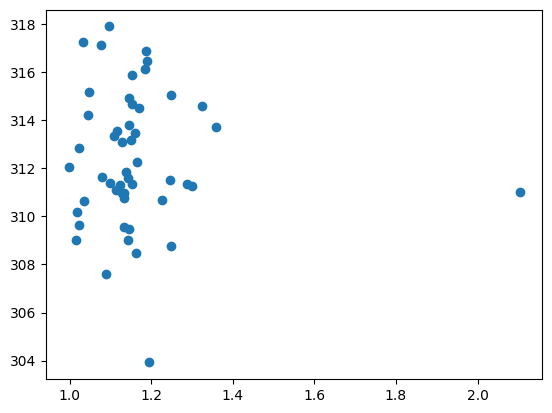

In [ ]:
plt.scatter(times, final_losses)

# Numba Implementation

In [20]:
import numpy as np
from numba import njit, prange

In [21]:
@njit
def OMP_numba(Y, T_0, D, batch_size=1, seed=42, debug=False):
    # Use np.random.seed for Numba compatibility instead of Generator
    np.random.seed(seed)
    
    n_samples, n_features = Y.shape
    n_atoms = D.shape[0]
    
    # X = np.zeros((n_samples, n_atoms), order='F')
    X = np.asfortranarray(np.zeros((n_samples, n_atoms))) # compatible w numba

    # Pre-calculate norms using numpy.linalg (numba compatible)
    D_norm = np.zeros(n_atoms)
    for i in range(n_atoms):
        D_norm[i] = np.linalg.norm(D[i, :])

    # Manual batching instead of np.split
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        current_batch_size = end_idx - start_idx
        
        y = Y[start_idx:end_idx]
        r = y.copy()
        
        # Initialize storage for this batch
        I = np.zeros((current_batch_size, T_0), dtype=np.int32)
        Q = np.zeros((current_batch_size, n_features, T_0))
        Q_T_y = np.zeros((current_batch_size, T_0))
        R = np.zeros((current_batch_size, T_0, T_0))
        atom_mask = np.ones((current_batch_size, n_atoms))
        global_dead_batches = np.zeros(current_batch_size, dtype=np.bool_)
        
        j_stop = T_0
        
        for j in range(T_0):
            if np.all(global_dead_batches):
                j_stop = j
                break

            # Batched Correlation: (B, F) @ (F, K) -> (B, K)
            D_r = r @ D.T
            D_r *= atom_mask
            
            # Find best atoms
            for b in range(current_batch_size):
                if global_dead_batches[b]:
                    continue
                
                k_idx = np.argmax(np.abs(D_r[b]))
                I[b, j] = k_idx
                atom_mask[b, k_idx] = 0
                
                # Gram-Schmidt Step
                D_k = D[k_idx]
                
                if j == 0:
                    norm_val = D_norm[k_idx]
                    R[b, 0, 0] = norm_val
                    Q[b, :, 0] = D_k / norm_val
                else:
                    # dot: (j,) projection of D_k onto previous Q atoms
                    dot = Q[b, :, :j].T @ D_k
                    R[b, 0:j, j] = dot
                    
                    q_j = D_k - Q[b, :, :j] @ dot
                    q_j_norm = np.linalg.norm(q_j)
                    
                    if q_j_norm < 1e-15:
                        global_dead_batches[b] = True
                        R[b, j, j] = 1.0 # Stability
                    else:
                        R[b, j, j] = q_j_norm
                        Q[b, :, j] = q_j / q_j_norm
                
                # Update residual for this sample
                proj_val = np.dot(y[b], Q[b, :, j])
                Q_T_y[b, j] = proj_val
                r[b] -= Q[b, :, j] * proj_val

        # Solve for coefficients after the loop
        for b in range(current_batch_size):
            # Using standard np.linalg.solve for the triangular system
            # (Note: np.linalg.solve is supported, but ensure R is non-singular)
            actual_j = j_stop 
            if actual_j > 0:
                # gamma shape: (actual_j,)
                gamma = np.linalg.solve(R[b, :actual_j, :actual_j], Q_T_y[b, :actual_j])
                
                # Assign to sparse matrix X
                for idx in range(actual_j):
                    atom_pos = I[b, idx]
                    X[start_idx + b, atom_pos] = gamma[idx]

    return X

In [22]:
@njit
def kSVD_numba(Y, T_0, k, num_iter, batch_size=1, verbose=0, seed=42):
    # Numba-compatible random initialization
    np.random.seed(seed)
    
    n_samples, n_features = Y.shape
    loss = np.zeros(num_iter)
    
    # Initialize dictionary with random normal atoms
    D = np.random.standard_normal((k, n_features))
    
    # Normalize atoms: D /= ||D||_2
    for i in range(k):
        norm_val = np.linalg.norm(D[i])
        if norm_val > 1e-12:
            D[i] /= norm_val

    for iteration in range(num_iter):      
        # 1. Sparse Coding Step (OMP)
        # Pass the seed or let OMP use the current global state
        X = OMP_numba(Y, T_0, D, batch_size=batch_size, seed=seed+iteration)
        
        # 2. Dictionary Update Step
        # Precompute the residual E = Y - XD
        E_k_R = Y - (X @ D)
        unused_atom = False
        
        for i in range(k):
            # Find samples that use the i-th atom
            # Numba's np.flatnonzero is efficient here
            indices = np.flatnonzero(X[:, i])
            
            if indices.shape[0] == 0:
                unused_atom = True
                continue
            
            # Temporarily remove the i-th atom contribution from the residual
            # This is equivalent to E_k = Y - sum_{j \neq i} d_j x_j
            for idx in indices:
                E_k_R[idx] += X[idx, i] * D[i]

            # Restricted SVD on the samples that use this atom
            # We only need the top singular vector/value
            E_subset = np.empty((indices.shape[0], n_features))
            for j in range(indices.shape[0]):
                E_subset[j] = E_k_R[indices[j]]
            
            # np.linalg.svd is supported in @njit
            U, S, Vh = np.linalg.svd(E_subset, full_matrices=False)


            # Update atom and its coefficients
            X[indices, i] = U[:, 0] * S[0]
            D[i] = Vh[0]

            # Add the updated contribution back to the residual
            for j in range(indices.shape[0]):
                idx = indices[j]
                E_k_R[idx] -= X[idx, i] * D[i]

        # Calculate Frobenius norm of the residual
        loss[iteration] = np.linalg.norm(E_k_R)

    return D, loss

In [23]:
@njit(parallel=True)
def kSVD_numba_specified(Y, T_0, k, num_iter, batch_size=1, verbose=0, seed=42):
    # Numba-compatible random initialization
    np.random.seed(seed)
    
    n_samples, n_features = Y.shape
    loss = np.zeros(num_iter)
    
    # Initialize dictionary with random normal atoms
    D = np.random.standard_normal((k, n_features))
    
    # Normalize atoms: D /= ||D||_2
    for i in prange(k):
        norm_val = np.linalg.norm(D[i])
        if norm_val > 1e-12:
            D[i] /= norm_val

    for iteration in range(num_iter):      
        # 1. Sparse Coding Step (OMP)
        # Pass the seed or let OMP use the current global state
        X = OMP_numba(Y, T_0, D, batch_size=batch_size, seed=seed+iteration)
        
        # 2. Dictionary Update Step
        # Precompute the residual E = Y - XD
        E_k_R = Y - (X @ D)
        unused_atom = False
        
        for i in range(k):
            # Find samples that use the i-th atom
            # Numba's np.flatnonzero is efficient here
            indices = np.flatnonzero(X[:, i])
            
            if indices.shape[0] == 0:
                unused_atom = True
                continue
            
            # Temporarily remove the i-th atom contribution from the residual
            # This is equivalent to E_k = Y - sum_{j \neq i} d_j x_j
            for idx in indices:
                E_k_R[idx] += X[idx, i] * D[i]

            # Restricted SVD on the samples that use this atom
            # We only need the top singular vector/value
            E_subset = np.empty((indices.shape[0], n_features))
            for j in range(indices.shape[0]):
                E_subset[j] = E_k_R[indices[j]]
            
            # np.linalg.svd is supported in @njit
            U, S, Vh = np.linalg.svd(E_subset, full_matrices=False)


            # Update atom and its coefficients
            X[indices, i] = U[:, 0] * S[0]
            D[i] = Vh[0]

            # Add the updated contribution back to the residual
            for j in range(indices.shape[0]):
                idx = indices[j]
                E_k_R[idx] -= X[idx, i] * D[i]

        # Calculate Frobenius norm of the residual
        loss[iteration] = np.linalg.norm(E_k_R)

    return D, loss

In [24]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples = 50, n_features = 300, n_targets = 20_000, noise=4, random_state=0)

In [25]:
OMP_numba(y.T, 1, X.T, batch_size=1)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(20000, 300))

In [26]:
%timeit OMP_numba(y.T, 1, X.T, batch_size=8)

101 ms ± 958 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [27]:
%%timeit
D, loss = kSVD_numba(Y = Y,
                T_0 = T_0, 
                k = 300, 
                num_iter = num_iter, 
                verbose=0,
                seed = 42,
                batch_size=8) 

/tmp/ipykernel_5888/1675360693.py:21: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 1, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  X = OMP_numba(Y, T_0, D, batch_size=batch_size, seed=seed+iteration)


1.35 s ± 21.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
import matplotlib.pyplot as plt

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
numba_ksvd_times = []
base_ksvd_times = []

for bs in batch_sizes:
    result = %timeit -o kSVD_improved(Y=Y, T_0=T_0, k=300, num_iter=num_iter, verbose=0, rng=rng, batch_size=bs)
    base_ksvd_times.append(result.average)

8.35 s ± 359 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
6.35 s ± 364 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.51 s ± 498 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.8 s ± 572 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.69 s ± 48.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.41 s ± 32.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.29 s ± 33.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.22 s ± 39.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.2 s ± 30.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
for bs in batch_sizes:
    # Time the kSVD_numba function with current batch size
    result = %timeit -o kSVD_numba(Y=Y, T_0=T_0, k=300, num_iter=num_iter, verbose=0, seed=42, batch_size=bs)
    numba_ksvd_times.append(result.average)

1.75 s ± 31.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.18 s ± 60.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.73 s ± 122 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.61 s ± 106 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.54 s ± 70.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.4 s ± 23.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.37 s ± 56.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.42 s ± 38.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.59 s ± 103 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


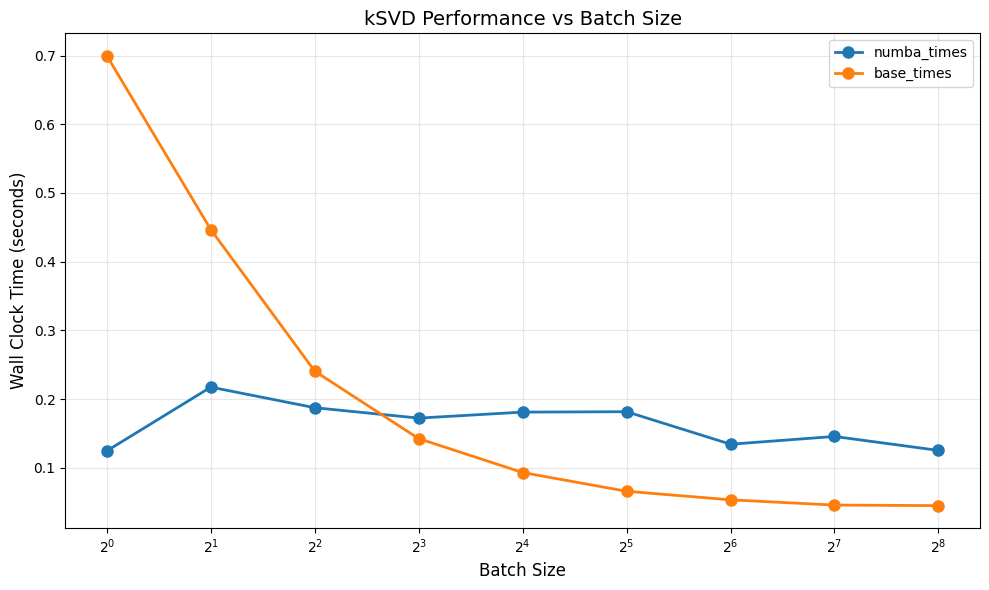

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, numba_ksvd_times, marker='o', linewidth=2, markersize=8)
plt.plot(batch_sizes, base_ksvd_times, marker='o', linewidth=2, markersize=8)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Wall Clock Time (seconds)', fontsize=12)
plt.title('kSVD Performance vs Batch Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.tight_layout()
plt.legend(['numba_times', 'base_times'])
plt.show()

In [ ]:
import matplotlib.pyplot as plt

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
numbaOMP_times = []
baseOMP_times = []

for bs in batch_sizes:
    result = %timeit -o OMP(y.T, 1, X.T, batch_size=bs, rng=42, debug=False)
    baseOMP_times.append(result.average)
    # Time the kSVD_numba function with current batch size

700 ms ± 22.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
447 ms ± 14.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
241 ms ± 9.83 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
142 ms ± 3.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
93 ms ± 2.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
65.7 ms ± 2.52 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
53.2 ms ± 812 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
45.6 ms ± 1.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
44.8 ms ± 628 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
125 ms ± 6.37 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
217 ms ± 41.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
187 ms ± 72.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
172 ms ± 55.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
181 ms ± 51.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
182 ms ± 37.3 ms per loop (mea

In [ ]:
for bs in batch_sizes:
    result = %timeit -o OMP_numba(y.T, 1, X.T, batch_size=bs)
    numbaOMP_times.append(result.average)

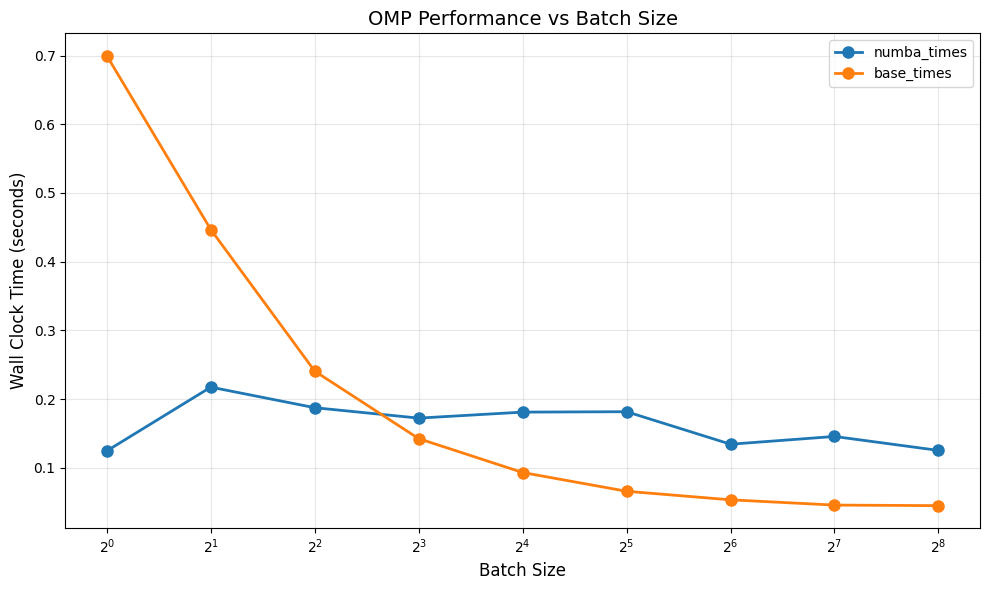

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, numbaOMP_times, marker='o', linewidth=2, markersize=8)
plt.plot(batch_sizes, baseOMP_times, marker='o', linewidth=2, markersize=8)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Wall Clock Time (seconds)', fontsize=12)
plt.title('OMP Performance vs Batch Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.tight_layout()
plt.legend(['numba_times', 'base_times'])
plt.show()

# Going a little deeper with the profiling

### See https://jakevdp.github.io/PythonDataScienceHandbook/01.07-timing-and-profiling.html for a few examples

### Requires line_profiler to be installed if you want to run the following code locally !!!

In [ ]:
# !pip install line_profiler

In [ ]:
%load_ext line_profiler

In [ ]:
# num_iter = 2
# Y = data

In [ ]:
from line_profiler import profile

## Baseline

In [ ]:
l_kSVD_baseline = profile(kSVD_baseline)
%lprun -f l_kSVD_baseline -f OMP_baseline l_kSVD_baseline(Y = Y, \
               T_0 = T_0, \
               k = 300, \
               num_iter = num_iter, \
                verbose=0, \
                rng = rng, batch_size = batch_size) 

Timer unit: 1e-09 s

Total time: 5.71695 s
File: /tmp/ipykernel_132406/1278657940.py
Function: kSVD_baseline at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def kSVD_baseline(Y, T_0, k, num_iter, batch_size = 1, track_loss = True, verbose:int = 0, rng=42):
     2         1      11958.0  11958.0      0.0      loss = np.empty(num_iter)
     3         1      36437.0  36437.0      0.0      rng = np.random.default_rng(rng)
     4                                           
     5                                               # Initialize dictionary
     6         1       2494.0   2494.0      0.0      t0 = time()
     7         1     565821.0 565821.0      0.0      D = rng.standard_normal(size=(k, Y.shape[1]))
     8         1     954456.0 954456.0      0.0      D /= LA.norm(D, ord=2, axis=1)[:, np.newaxis]
     9                                           
    10         1        777.0    777.0      0.0      if verbose

## Improved

In [ ]:
l_kSVD_improved = profile(kSVD_improved)
%lprun -f l_kSVD_improved -f OMP l_kSVD_improved(Y = Y, \
               T_0 = T_0, \
               k = 300, \
               num_iter = num_iter, \
                verbose=0, \
                rng = rng, batch_size=batch_size) 

Timer unit: 1e-09 s

Total time: 1.20692 s
File: /tmp/ipykernel_132406/1100116044.py
Function: kSVD_improved at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def kSVD_improved(Y, T_0, k, num_iter, batch_size = 1, track_loss = True, verbose:int = 0, rng=42):
     2         1      11028.0  11028.0      0.0      loss = np.empty(num_iter)
     3         1       5752.0   5752.0      0.0      rng = np.random.default_rng(rng)
     4                                           
     5                                               # Initialize dictionary
     6         1        811.0    811.0      0.0      t0 = time()
     7         1     692594.0 692594.0      0.1      D = rng.standard_normal(size=(k, Y.shape[1]))
     8         1     892196.0 892196.0      0.1      D /= LA.norm(D, ord=2, axis=1)[:, np.newaxis]
     9                                           
    10         1        673.0    673.0      0.0      if verbose

In [ ]:
l_kSVD_numba = profile(kSVD_numba)
%lprun -f l_kSVD_numba -f OMP_numba l_kSVD_numba(Y = Y,\
                T_0 = T_0, \
                k = 300, \
                num_iter = num_iter, \
                verbose=0,\
                seed = 42,\
                batch_size=batch_size)

/home/vsrinivasan/parallel_k-svd/serial_base/lib/python3.12/site-packages/line_profiler/ipython_extension.py:458: UserWarning: Adding a function with a `.__wrapped__` attribute. You may want to profile the wrapped function by adding `kSVD_numba.__wrapped__` instead.
  profile = LineProfiler(*funcs)
/home/vsrinivasan/parallel_k-svd/serial_base/lib/python3.12/site-packages/line_profiler/ipython_extension.py:458: UserWarning: Adding a function with a `.__wrapped__` attribute. You may want to profile the wrapped function by adding `OMP_numba.__wrapped__` instead.
  profile = LineProfiler(*funcs)


Timer unit: 1e-09 s

Total time: 0 s
File: /tmp/ipykernel_132406/1675360693.py
Function: kSVD_numba at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           @njit
     2                                           def kSVD_numba(Y, T_0, k, num_iter, batch_size=1, verbose=0, seed=42):
     3                                               # Numba-compatible random initialization
     4                                               np.random.seed(seed)
     5                                           
     6                                               n_samples, n_features = Y.shape
     7                                               loss = np.zeros(num_iter)
     8                                           
     9                                               # Initialize dictionary with random normal atoms
    10                                               D = np.random.standard_normal((k, n_features))
    11           

## Requires memory_profiler to be installed if you want to run the following code locally !!!

In [ ]:
# pip install memory_profiler

In [ ]:
%load_ext memory_profiler

In [ ]:
num_iter = 2
Y = data

## Baseline

In [ ]:
%memit kSVD_baseline(Y = Y, \
               T_0 = T_0, \
               k = 300, \
               num_iter = num_iter, \
                verbose=0, \
                rng = rng, batch_size=batch_size) 

peak memory: 648.00 MiB, increment: 133.31 MiB


## Improved

In [ ]:
%memit kSVD_improved(Y = Y, \
               T_0 = T_0, \
               k = 300, \
               num_iter = num_iter, \
              verbose=0, \
                rng = rng, batch_size=batch_size) 

peak memory: 647.92 MiB, increment: 120.03 MiB


In [ ]:
%memit kSVD_numba(Y = Y, \
               T_0 = T_0, \
               k = 300, \
               num_iter = num_iter, \
              verbose=0, \
                seed = 42, batch_size=batch_size) 

peak memory: 586.74 MiB, increment: 71.57 MiB
